<a href="https://colab.research.google.com/github/Huang-stat/Computer-Labs/blob/main/AKHU_CS_Lab4_JSON_Pickle_MultipleRegression_0514.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# CS Lab 4 - JSON, Pickle, and Multiple Regression Persistence

**Date:** Thursday, 14 May 2026, 16:00  
**Location:** Comp. Lab 1  
**Topic:** Advanced object persistence using JSON and pickle with package-based multiple regression

This notebook shows how these files work together:

| File type | Role in this lab |
|---|---|
| `.ipynb` or `.py` | Stores Python instructions. |
| `.csv` | Stores the raw student-score table. |
| `.json` | Stores readable configuration, reports, run history, and new prediction inputs. |
| `.pkl` | Stores a trusted Python model object or artifact. |

Main idea:

> A notebook or script stores the instructions. JSON and pickle files store settings, results, prediction inputs, and model state that survive after Python stops.

The regression model is a **multiple regression** model:

$$
\widehat{final\_score} = b_0 + b_1(hours\_studied) + b_2(quiz\_average) + b_3(attendance\_rate) + b_4(assignments\_submitted).
$$



## 1. Why JSON and pickle are needed, not just `.ipynb`

A notebook stores the **code and explanation**. It does not automatically save the model state in a reusable way.

For data analysis, we often need to save:

- the selected target and predictor columns;
- the fitted regression coefficients;
- the model metrics;
- the prediction records;
- the trained model object so we can predict later without fitting again.

Use this rule:

| Need | Good file type | Reason |
|---|---|---|
| Change model settings without editing code | JSON config | Human-readable settings file |
| Store model coefficients, metrics, predictions | JSON report | Readable after Python stops |
| Store a fitted Python model object | Pickle | Restores Python object state |
| Share with non-Python tools | JSON | Language independent |
| Save trusted internal Python object | Pickle | Python-specific and powerful |

**Security rule:** only unpickle files from this trusted lab bundle or files you created yourself.



## 2. Loading JSON and pickle files in Colab

### Option A: Upload files directly to Colab

In Colab:

1. Click the folder icon on the left.
2. Click **Upload**.
3. Upload files such as:

```text
AKHU_lab4_regression_config.json
AKHU_lab4_regression_artifact.pkl
AKHU_lab4_sklearn_linear_regression_model.pkl
```

After upload, Colab usually stores them in:

```text
/content/
```

Check with:

```python
from pathlib import Path

print("Current folder:", Path.cwd())
print("Files in /content:")
for file in Path("/content").glob("*"):
    print(file)
```

### Load a JSON file in Colab

```python
from pathlib import Path
import json

json_path = Path("/content/AKHU_lab4_regression_config.json")

with json_path.open("r", encoding="utf-8") as f:
    config = json.load(f)

print(type(config))
print(config)
```

### Load a pickle file in Colab

```python
from pathlib import Path
import pickle

pkl_path = Path("/content/AKHU_lab4_regression_artifact.pkl")

with pkl_path.open("rb") as f:
    artifact = pickle.load(f)

print(type(artifact))
print(artifact.keys())
```

Important: pickle uses `"rb"` because it is a **binary file**.



## 3. Loading files from Google Drive in Colab

This is better if you want the files to stay available after the Colab session ends.

### Mount Google Drive

```python
from google.colab import drive
drive.mount("/content/drive")
```

Put your files in Google Drive:

```text
MyDrive/AKHU_labs/
```

Then the Colab path is:

```text
/content/drive/MyDrive/AKHU_labs/
```

### Load JSON from Google Drive

```python
from pathlib import Path
import json

DATA_DIR = Path("/content/drive/MyDrive/AKHU_labs")
json_path = DATA_DIR / "AKHU_lab4_regression_config.json"

with json_path.open("r", encoding="utf-8") as f:
    config = json.load(f)

print(config)
```

### Load pickle from Google Drive

```python
from pathlib import Path
import pickle

DATA_DIR = Path("/content/drive/MyDrive/AKHU_labs")
pkl_path = DATA_DIR / "AKHU_lab4_regression_artifact.pkl"

with pkl_path.open("rb") as f:
    artifact = pickle.load(f)

print(artifact.keys())
```



## 4. Loading JSON and pickle files in Visual Studio Code / Visual Studio

In VS Code, the cleanest setup is:

```text
your_project_folder/
    lab4_notebook.ipynb
    data/
        AKHU_lab4_regression_config.json
        AKHU_lab4_new_students_for_prediction.json
        AKHU_lab4_student_scores_regression.csv
    models/
        AKHU_lab4_regression_artifact.pkl
        AKHU_lab4_sklearn_linear_regression_model.pkl
    outputs/
```

Open the **whole project folder**, not only the notebook file.

### Check your current working directory

```python
from pathlib import Path

print("Current working directory:")
print(Path.cwd())

print("\nFiles here:")
for file in Path.cwd().glob("*"):
    print(file)
```

If your notebook is in the project folder, `Path.cwd()` should show that folder.

### Load JSON in VS Code

```python
from pathlib import Path
import json

json_path = Path("data") / "AKHU_lab4_regression_config.json"

with json_path.open("r", encoding="utf-8") as f:
    config = json.load(f)

print(type(config))
print(config)
```

For new-student prediction input:

```python
new_students_path = Path("data") / "AKHU_lab4_new_students_for_prediction.json"

with new_students_path.open("r", encoding="utf-8") as f:
    new_students = json.load(f)

print(new_students)
```

### Load pickle in VS Code

```python
from pathlib import Path
import pickle

pkl_path = Path("models") / "AKHU_lab4_regression_artifact.pkl"

with pkl_path.open("rb") as f:
    artifact = pickle.load(f)

print(type(artifact))
print(artifact.keys())
```

If loading the saved scikit-learn model directly:

```python
from pathlib import Path
import pickle

model_path = Path("models") / "AKHU_lab4_sklearn_linear_regression_model.pkl"

with model_path.open("rb") as f:
    model = pickle.load(f)

print(type(model))
```



## 5. Recommended helper function for both Colab and VS Code

The next code cell is executable. It searches common folders used in Colab and VS Code.


In [1]:

from pathlib import Path
import json
import pickle
import math
import sys

print("Current working directory:", Path.cwd())

def find_file(filename):
    candidate_dirs = [
        Path("."),                                  # current folder
        Path("data"),                              # VS Code data folder
        Path("models"),                            # VS Code model folder
        Path("outputs"),                           # VS Code output folder
        Path("/content"),                          # Colab upload folder
        Path("/content/data"),                     # Colab data folder
        Path("/content/drive/MyDrive/AKHU_labs"),  # Colab Google Drive folder
    ]

    print("Searching for:", filename)
    for folder in candidate_dirs:
        candidate = folder / filename
        print("Checking:", candidate)
        if candidate.exists():
            print("Found:", candidate)
            return candidate

    raise FileNotFoundError(
        f"Could not find {filename}. Put it in data/, models/, /content/, "
        "or /content/drive/MyDrive/AKHU_labs."
    )

# Create output folders for this notebook run.
Path("outputs").mkdir(exist_ok=True)
Path("models").mkdir(exist_ok=True)
Path("assets").mkdir(exist_ok=True)


Current working directory: /content



## 6. Load JSON config and inspect it

This JSON file controls the regression setup. It tells Python:

- which CSV file to load;
- which column is the target;
- which columns are predictors;
- how many rows to use for training;
- what output filenames to use.


In [2]:

json_path = find_file("AKHU_lab4_regression_config.json")

with json_path.open("r", encoding="utf-8") as f:
    config = json.load(f)

print("JSON path:", json_path)
print("Type:", type(config))
print(json.dumps(config, indent=4))


Searching for: AKHU_lab4_regression_config.json
Checking: AKHU_lab4_regression_config.json
Found: AKHU_lab4_regression_config.json
JSON path: AKHU_lab4_regression_config.json
Type: <class 'dict'>
{
    "lab": "CS Lab 4 - JSON and Pickle Persistence for Multiple Regression",
    "created_for": "May 14 computer lab",
    "data_file": "AKHU_lab4_student_scores_regression.csv",
    "target": "final_score",
    "features": [
        "hours_studied",
        "quiz_average",
        "attendance_rate",
        "assignments_submitted"
    ],
    "train_rows": 24,
    "model_type": "sklearn.linear_model.LinearRegression",
    "metrics": [
        "MAE",
        "RMSE",
        "R2"
    ],
    "output_json_report": "AKHU_lab4_regression_report.json",
    "output_pickle_artifact": "AKHU_lab4_regression_artifact.pkl",
    "security_note": "Only load pickle files from trusted sources. JSON is safer for sharing reports and configuration."
}



## 7. Optional: load an existing trusted pickle artifact

This demonstrates how to open a pickle file properly. The file must be trusted.

If this file is not present yet, continue the notebook. Later cells will create a new pickle artifact.


In [3]:

try:
    pkl_path = find_file("AKHU_lab4_regression_artifact.pkl")
    with pkl_path.open("rb") as f:
        artifact = pickle.load(f)
    print("Pickle path:", pkl_path)
    print("Type:", type(artifact))
    print("Keys:", artifact.keys())
    print("Feature order:", artifact.get("features"))
except FileNotFoundError:
    print("No existing pickle artifact found. The notebook will create one later.")
except Exception as exc:
    print("A pickle file was found, but it could not be loaded in this Python environment.")
    print("This can happen if package versions are incompatible.")
    print("Error:", repr(exc))


Searching for: AKHU_lab4_regression_artifact.pkl
Checking: AKHU_lab4_regression_artifact.pkl
Checking: data/AKHU_lab4_regression_artifact.pkl
Checking: models/AKHU_lab4_regression_artifact.pkl
Checking: outputs/AKHU_lab4_regression_artifact.pkl
Checking: /content/AKHU_lab4_regression_artifact.pkl
Checking: /content/data/AKHU_lab4_regression_artifact.pkl
Checking: /content/drive/MyDrive/AKHU_labs/AKHU_lab4_regression_artifact.pkl
No existing pickle artifact found. The notebook will create one later.



## 8. Key difference between JSON and pickle loading

| File type | Load mode | Python function | Human readable? | Main purpose |
|---|---|---|---|---|
| `.json` | `"r"` | `json.load(f)` | Yes | Configs, reports, predictions |
| `.pkl` | `"rb"` | `pickle.load(f)` | No | Saved Python objects, trained models |

Security warning:

> Only load pickle files created by your own code or received from the trusted lab bundle. A pickle file can execute Python code while loading.



## 9. Import packages for package-based multiple regression

This lab uses packages because the focus is on **using persistence files in a realistic modeling workflow**, not writing regression from scratch.

Packages:

- `pandas` for tables;
- `numpy` for numerical arrays;
- `scikit-learn` for `LinearRegression` and metrics;
- `matplotlib` for plots.

In VS Code, install packages from the terminal if needed:

```text
python -m pip install pandas numpy scikit-learn matplotlib
```


In [4]:

try:
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.linear_model import LinearRegression
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
except ImportError as exc:
    print("A required package is missing.")
    print("In VS Code, run: python -m pip install pandas numpy scikit-learn matplotlib")
    raise exc

print("Packages imported successfully.")


Packages imported successfully.



## 10. Load the CSV data using the JSON config

The JSON config makes the code more flexible. If the data file or feature list changes, update the JSON instead of editing many code cells.


In [5]:

csv_path = find_file(config["data_file"])
df = pd.read_csv(csv_path)

print("CSV path:", csv_path)
print("Shape:", df.shape)
df.head()


Searching for: AKHU_lab4_student_scores_regression.csv
Checking: AKHU_lab4_student_scores_regression.csv
Found: AKHU_lab4_student_scores_regression.csv
CSV path: AKHU_lab4_student_scores_regression.csv
Shape: (30, 7)


,student_id,hours_studied,quiz_average,attendance_rate,assignments_submitted,participation_score,final_score
0,S01,1.2,52,0.58,4,45,50
1,S02,1.6,55,0.62,4,48,53
2,S03,2.0,58,0.65,5,52,57
3,S04,2.2,60,0.67,5,55,60
4,S05,2.5,63,0.70,6,58,64



## 11. Select multiple predictors and the target

The target is:

```text
final_score
```

The predictors are loaded from the JSON config:

```text
hours_studied
quiz_average
attendance_rate
assignments_submitted
```


In [6]:

features = config["features"]
target = config["target"]
train_rows = int(config["train_rows"])

print("Target column:", target)
print("Predictor columns:", features)

train_df = df.iloc[:train_rows].copy()
test_df = df.iloc[train_rows:].copy()

X_train = train_df[features]
y_train = train_df[target]
X_test = test_df[features]
y_test = test_df[target]

print("Train rows:", len(train_df))
print("Test rows:", len(test_df))
X_train.head()


Target column: final_score
Predictor columns: ['hours_studied', 'quiz_average', 'attendance_rate', 'assignments_submitted']
Train rows: 24
Test rows: 6


,hours_studied,quiz_average,attendance_rate,assignments_submitted
0,1.2,52,0.58,4
1,1.6,55,0.62,4
2,2.0,58,0.65,5
3,2.2,60,0.67,5
4,2.5,63,0.70,6



## 12. Fit a baseline model and a package multiple-regression model

The mean baseline predicts the average training score for every test student.

The package model uses:

```python
sklearn.linear_model.LinearRegression
```


In [7]:

# Mean baseline
baseline_prediction = float(y_train.mean())
y_pred_baseline = np.full(shape=len(y_test), fill_value=baseline_prediction)

# Package multiple regression
model = LinearRegression()
model.fit(X_train, y_train)
y_pred_regression = model.predict(X_test)

print("Mean baseline prediction:", round(baseline_prediction, 3))
print("Regression intercept:", round(float(model.intercept_), 3))
print("Regression coefficients:")
for name, coef in zip(features, model.coef_):
    print(f"  {name}: {coef:.4f}")


Mean baseline prediction: 71.833
Regression intercept: 8.06
Regression coefficients:
  hours_studied: 5.4281
  quiz_average: 0.6032
  attendance_rate: 1.8210
  assignments_submitted: 0.4871



## 13. Compare model performance

Metrics:

- **MAE:** mean absolute error. Smaller is better.
- **RMSE:** root mean squared error. Smaller is better.
- **R2:** coefficient of determination. Larger is better.


In [8]:

def regression_metrics(y_true, y_pred):
    return {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(math.sqrt(mean_squared_error(y_true, y_pred))),
        "R2": float(r2_score(y_true, y_pred)),
    }

metrics_baseline = regression_metrics(y_test, y_pred_baseline)
metrics_regression = regression_metrics(y_test, y_pred_regression)

comparison = pd.DataFrame([
    {"model": "Mean baseline", **metrics_baseline},
    {"model": "Package multiple regression", **metrics_regression},
])
comparison


,model,MAE,RMSE,R2
0,Mean baseline,13.50000,15.489244,-0.048561
1,Package multiple regression,0.97543,1.117684,0.994540



## 14. Result plots

The plots are ordinary notebook outputs. They are not needed for JSON/pickle loading, but they help read the model result.


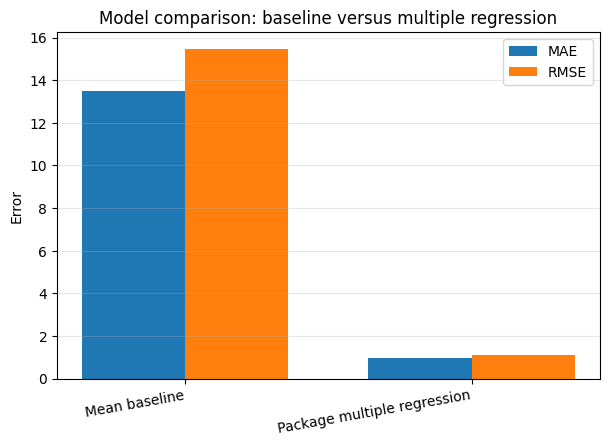

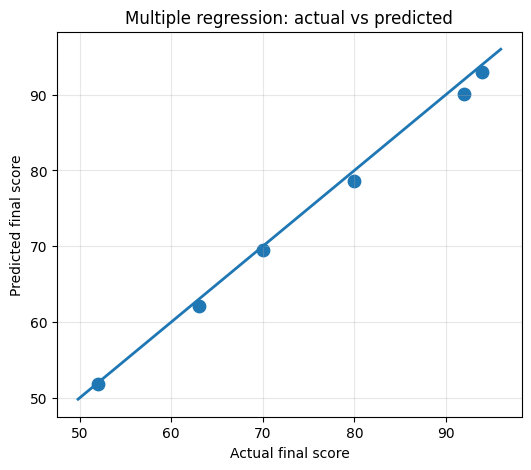

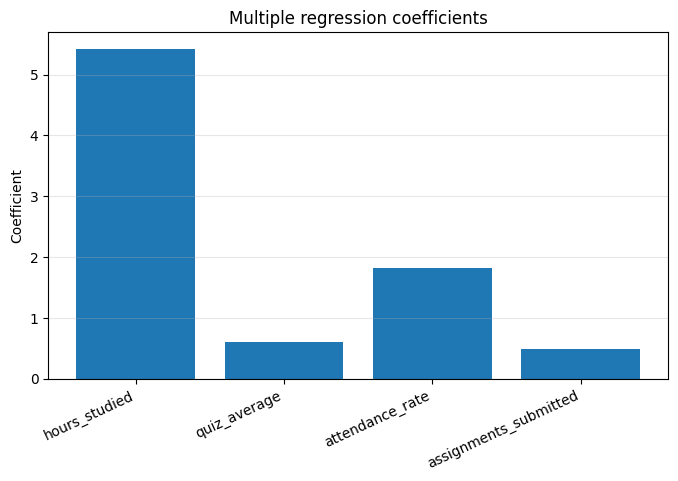

In [9]:

ASSETS_DIR = Path("assets")
ASSETS_DIR.mkdir(exist_ok=True)

# Plot 1: model comparison
x = np.arange(len(comparison))
plt.figure(figsize=(7, 4.5))
plt.bar(x - 0.18, comparison["MAE"], width=0.36, label="MAE")
plt.bar(x + 0.18, comparison["RMSE"], width=0.36, label="RMSE")
plt.xticks(x, comparison["model"], rotation=10, ha="right")
plt.ylabel("Error")
plt.title("Model comparison: baseline versus multiple regression")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.savefig(ASSETS_DIR / "model_comparison_multiple_regression.png", dpi=160, bbox_inches="tight")
plt.show()

# Plot 2: actual vs predicted
plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred_regression, s=80)
low = min(y_test.min(), y_pred_regression.min()) - 2
high = max(y_test.max(), y_pred_regression.max()) + 2
plt.plot([low, high], [low, high], linewidth=2)
plt.xlabel("Actual final score")
plt.ylabel("Predicted final score")
plt.title("Multiple regression: actual vs predicted")
plt.grid(True, alpha=0.3)
plt.savefig(ASSETS_DIR / "actual_vs_predicted_multiple_regression.png", dpi=160, bbox_inches="tight")
plt.show()

# Plot 3: coefficients
coef_table = pd.DataFrame({"feature": features, "coefficient": model.coef_})
plt.figure(figsize=(8, 4.5))
plt.bar(coef_table["feature"], coef_table["coefficient"])
plt.ylabel("Coefficient")
plt.title("Multiple regression coefficients")
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.savefig(ASSETS_DIR / "multiple_regression_coefficients.png", dpi=160, bbox_inches="tight")
plt.show()



## 15. Save a readable JSON regression report

A JSON report helps modeling and data analysis because it preserves model facts after the notebook stops.

The JSON report stores:

- target and feature names;
- intercept and coefficients;
- baseline metrics;
- multiple-regression metrics;
- test predictions.

JSON is the right format for this report because it can be opened in a text editor.


In [10]:

coefficients = {name: float(coef) for name, coef in zip(features, model.coef_)}

prediction_rows = []
for student_id, actual, predicted in zip(test_df["student_id"], y_test, y_pred_regression):
    prediction_rows.append({
        "student_id": student_id,
        "actual_final_score": float(actual),
        "predicted_final_score": round(float(predicted), 3),
        "residual": round(float(actual - predicted), 3),
    })

report = {
    "report_type": "multiple_regression_json_report",
    "important_message": "This JSON file stores readable model facts and results, not the trained Python object.",
    "why_json_helps": [
        "The feature list and target can be recorded without editing the notebook.",
        "The coefficients, metrics, and predictions remain available after the Python session ends.",
        "The report can be opened in a text editor or shared with non-Python tools.",
    ],
    "model_type": config["model_type"],
    "data_file": config["data_file"],
    "target": target,
    "features": features,
    "train_rows": train_rows,
    "test_rows": len(test_df),
    "intercept": float(model.intercept_),
    "coefficients": coefficients,
    "baseline_metrics": metrics_baseline,
    "regression_metrics": metrics_regression,
    "test_predictions": prediction_rows,
}

report_path = Path("outputs") / config.get("output_report", config.get("output_json_report", "AKHU_lab4_regression_report_from_notebook.json"))
with report_path.open("w", encoding="utf-8") as f:
    json.dump(report, f, indent=4)

print("Saved JSON report to:", report_path)
print(json.dumps(report, indent=4)[:1200] + "\n...")


Saved JSON report to: outputs/AKHU_lab4_regression_report.json
{
    "report_type": "multiple_regression_json_report",
    "important_message": "This JSON file stores readable model facts and results, not the trained Python object.",
    "why_json_helps": [
        "The feature list and target can be recorded without editing the notebook.",
        "The coefficients, metrics, and predictions remain available after the Python session ends.",
        "The report can be opened in a text editor or shared with non-Python tools."
    ],
    "model_type": "sklearn.linear_model.LinearRegression",
    "data_file": "AKHU_lab4_student_scores_regression.csv",
    "target": "final_score",
    "features": [
        "hours_studied",
        "quiz_average",
        "attendance_rate",
        "assignments_submitted"
    ],
    "train_rows": 24,
    "test_rows": 6,
    "intercept": 8.060076298612742,
    "coefficients": {
        "hours_studied": 5.428136744104028,
        "quiz_average": 0.603181146922


## 16. Why JSON cannot directly save the trained model object

JSON is good for dictionaries, lists, strings, numbers, booleans, and `null`.

A trained `LinearRegression` object contains Python-specific object state and methods. JSON does not know how to represent that object.


In [11]:

try:
    json.dumps(model)
except TypeError as exc:
    print("JSON cannot save the trained model object directly.")
    print("Error message:", exc)


JSON cannot save the trained model object directly.
Error message: Object of type LinearRegression is not JSON serializable



## 17. Save a trusted pickle model artifact

Pickle helps modeling because it can restore the fitted Python model object.

This means a later notebook or script can make predictions without refitting the model.

Security rule:

> Only unpickle files from this trusted lab bundle or files created by your own code.


In [12]:

artifact = {
    "artifact_type": "trusted_python_pickle_model_artifact",
    "warning": "Only unpickle this file if it came from the trusted lab bundle or your own notebook run.",
    "why_pickle_helps": "Pickle restores the trained Python model object, so Python can make new predictions without refitting.",
    "model": model,
    "features": features,
    "target": target,
    "metrics": metrics_regression,
    "coefficients": coefficients,
    "intercept": float(model.intercept_),
}

pickle_path = Path("models") / config["output_pickle_artifact"]
with pickle_path.open("wb") as f:
    pickle.dump(artifact, f)

sklearn_model_path = Path("models") / "AKHU_lab4_sklearn_linear_regression_model.pkl"
with sklearn_model_path.open("wb") as f:
    pickle.dump(model, f)

print("Saved trusted pickle artifact to:", pickle_path)
print("Saved direct sklearn model pickle to:", sklearn_model_path)
print("Pickle files are binary. First 80 bytes:")
print(pickle_path.read_bytes()[:80])


Saved trusted pickle artifact to: models/AKHU_lab4_regression_artifact.pkl
Saved direct sklearn model pickle to: models/AKHU_lab4_sklearn_linear_regression_model.pkl
Pickle files are binary. First 80 bytes:
b'\x80\x04\x95\x8b\x04\x00\x00\x00\x00\x00\x00}\x94(\x8c\rartifact_type\x94\x8c$trusted_python_pickle_model_artifact\x94\x8c\x07warning\x94\x8c'



## 18. Load the JSON report and pickle artifact

This is the persistence test:

- JSON reloads readable facts and metrics.
- Pickle reloads the trusted Python model object.


In [13]:

with report_path.open("r", encoding="utf-8") as f:
    loaded_report = json.load(f)

with pickle_path.open("rb") as f:
    loaded_artifact = pickle.load(f)

loaded_model = loaded_artifact["model"]
loaded_features = loaded_artifact["features"]

print("Loaded JSON report type:", loaded_report["report_type"])
print("Loaded JSON features:", loaded_report["features"])
print("Loaded pickle warning:", loaded_artifact["warning"])
print("Loaded pickle features:", loaded_features)


Loaded JSON report type: multiple_regression_json_report
Loaded JSON features: ['hours_studied', 'quiz_average', 'attendance_rate', 'assignments_submitted']
Loaded pickle warning: Only unpickle this file if it came from the trusted lab bundle or your own notebook run.
Loaded pickle features: ['hours_studied', 'quiz_average', 'attendance_rate', 'assignments_submitted']



## 19. Use the loaded pickle model for prediction

Assume the model uses these features:

```python
features = [
    "hours_studied",
    "quiz_average",
    "attendance_rate",
    "assignments_submitted"
]
```

Then a new student must be entered in the same order:

```python
new_X = [[4.0, 78, 0.86, 8]]
prediction = model.predict(new_X)
print("Predicted final score:", prediction[0])
```

The next cell uses a JSON input file so that new records are separated from the code.


In [14]:

new_students_path = find_file("AKHU_lab4_new_students_for_prediction.json")
with new_students_path.open("r", encoding="utf-8") as f:
    new_students = json.load(f)

new_df = pd.DataFrame(new_students["records"])
new_predictions = loaded_model.predict(new_df[loaded_features])

new_prediction_report = {
    "prediction_report_type": "new_student_predictions_from_loaded_pickle_model",
    "source_pickle_model": str(pickle_path),
    "input_json": str(new_students_path),
    "feature_order": loaded_features,
    "predictions": [
        {"student_id": sid, "predicted_final_score": round(float(pred), 3)}
        for sid, pred in zip(new_df["student_id"], new_predictions)
    ],
}

new_pred_path = Path("outputs") / "AKHU_lab4_new_student_predictions_from_notebook.json"
with new_pred_path.open("w", encoding="utf-8") as f:
    json.dump(new_prediction_report, f, indent=4)

print("Saved prediction JSON to:", new_pred_path)
print(json.dumps(new_prediction_report, indent=4))


Searching for: AKHU_lab4_new_students_for_prediction.json
Checking: AKHU_lab4_new_students_for_prediction.json
Found: AKHU_lab4_new_students_for_prediction.json
Saved prediction JSON to: outputs/AKHU_lab4_new_student_predictions_from_notebook.json
{
    "prediction_report_type": "new_student_predictions_from_loaded_pickle_model",
    "source_pickle_model": "models/AKHU_lab4_regression_artifact.pkl",
    "input_json": "AKHU_lab4_new_students_for_prediction.json",
    "feature_order": [
        "hours_studied",
        "quiz_average",
        "attendance_rate",
        "assignments_submitted"
    ],
    "predictions": [
        {
            "student_id": "N01",
            "predicted_final_score": 65.011
        },
        {
            "student_id": "N02",
            "predicted_final_score": 79.955
        },
        {
            "student_id": "N03",
            "predicted_final_score": 93.06
        }
    ]
}



## 20. Optional QR decomposition check

`scikit-learn` is the main modeling tool in this lab. QR decomposition is included as an optional linear-algebra check.

The design matrix includes an intercept column of ones.


In [15]:

X_design = np.column_stack([np.ones(len(X_train)), X_train.to_numpy(dtype=float)])
y_values = y_train.to_numpy(dtype=float)

Q, R = np.linalg.qr(X_design)
beta_qr = np.linalg.solve(R, Q.T @ y_values)

beta_sklearn = np.concatenate([[model.intercept_], model.coef_])
coef_compare = pd.DataFrame({
    "term": ["intercept"] + features,
    "sklearn": beta_sklearn,
    "qr_solution": beta_qr,
    "difference": beta_sklearn - beta_qr,
})
coef_compare


,term,sklearn,qr_solution,difference
0,intercept,8.060076,8.060076,1.509903e-13
1,hours_studied,5.428137,5.428137,4.352074e-14
2,quiz_average,0.603181,0.603181,-3.885781e-15
3,attendance_rate,1.821030,1.821030,-1.532108e-14
4,assignments_submitted,0.487126,0.487126,-1.221245e-15



## 21. Practice tasks

1. Open `AKHU_lab4_regression_config.json`. Identify the target and features.
2. Remove one feature from the JSON feature list. Rerun the model and compare metrics.
3. Change `train_rows` from `24` to `20`. Rerun the model and compare metrics.
4. Add a new student to `AKHU_lab4_new_students_for_prediction.json`. Rerun the prediction section.
5. Open the JSON report in a text editor. Identify the coefficients and metrics.
6. Open the pickle file in a text editor. Explain why it looks unreadable.
7. Load the pickle file with Python and print `artifact.keys()`.
8. Explain why JSON is safer to share than pickle.

Final summary:

> A notebook or script stores instructions. JSON stores readable configuration, reports, prediction inputs, and run history. Pickle stores trusted Python object state, such as a fitted regression model.
